# 该脚本用于生成一维反演的初始模型

该初始模型是一维层状模型，对应深度的波速取值为 Crust 1.0 模型的水平平均值

In [ ]:
# 载入 PyTomoATT 模块
# 文档：https://tomoatt.github.io/PyTomoATT/index.html

import pytomoatt as pta

import numpy as np

# 1. 创建 PyTomoATT 模型对象

In [13]:
# TomoATT 参数文件目录，主要用于读取文件中的研究范围
par_file = "../3_input_params/input_params_step1_1D_inv.yaml"

# 读取参数文件，生成 ATTModel 对象
att_model = pta.ATTModel(par_file)

# 该模型的三维网格信息包括
n_rtp          = att_model.n_rtp       # 三个方向的网格节点数 r (depth), t (longtitude), p (latitude) directions
am_depths      = att_model.depths      # r方向 深度 (km)
am_latitudes   = att_model.latitudes   # p方向 纬度 (degree)
am_longitudes  = att_model.longitudes  # t方向 经度 (degree)

# 输出查看网格坐标信息
# print("grid node numbers (N_r, N_t, N_p):", n_rtp)
# print("depths (km):", am_depths)
# print("latitudes (degree):", am_latitudes)
# print("longitudes (degree):", am_longitudes)

In [14]:
# 区域旋转参数
central_lat = 37.0      # 旋转中心纬度
central_lon = 37.0      # 旋转中心经度
rotation_angle = 45.0   # 顺时针旋转角度

# 生成crust 1.0 模型
# 注释：如果不需要旋转，则可以将 rotate 设置为 None
rotate = [central_lat, central_lon, rotation_angle]
att_model.grid_data_crust1(rotate=rotate)

2026-07-29 15:02:46,957 [Model] INFO: Grid data, please wait for a few minutes
Gridding: 100%|██████████| 1891/1891 [00:00<00:00, 20499.68it/s]


# 2. 生成平均一维模型（可选）

反演的初始模型可以是一维模型，常见的方法是做水平平均。该脚本介绍这种方法。

此外，反演的初始模型还可以是三维模型，常见的做法有：使用已有的模型，插值得到研究区域的三维速度。在该三维模型基础上，添加适当的光滑化，例如高斯光滑，降低反演收敛到局部极小的风险。

In [15]:
# 获得三维模型数组
vel_3d_array = att_model.vel

# 计算其水平平均值，作为一维模型
vel_1d_array = np.mean(vel_3d_array, axis=(1,2))

# 广播到三维模型
att_model.vel = np.broadcast_to(vel_1d_array[:, np.newaxis, np.newaxis], vel_3d_array.shape)

In [16]:
# 写入到文件
import os
output_path = "./output_model"
os.makedirs(output_path, exist_ok=True)

fname = "%s/model_1d_crust1.0_N%d_%d_%d.h5" % (output_path, n_rtp[0], n_rtp[1], n_rtp[2])
att_model.write(fname)


# 备份一份到主目录
output_path = "../2_models"
os.makedirs(output_path, exist_ok=True)
fname = "%s/model_1d_crust1.0_N%d_%d_%d.h5" % (output_path, n_rtp[0], n_rtp[1], n_rtp[2])
att_model.write(fname)

# 3. 一维模型画图（可选）

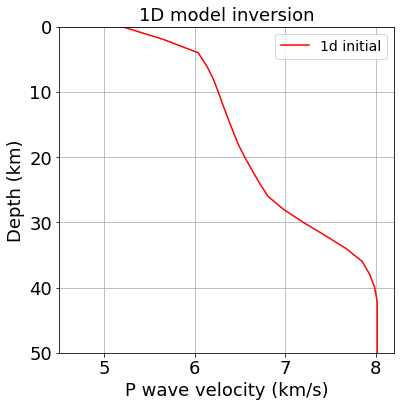

In [17]:
att_model_1d = pta.ATTModel.read(fname,par_file)

all_dep = np.array(att_model_1d.depths)

vel_1d = np.array(att_model_1d.vel[:, 0, 0])


# 层状模型画图
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6,6))
gridspace = GridSpec(6,6,figure = fig)
ax2 = fig.add_subplot(gridspace[0:6, 0:6])


ax2.plot(vel_1d,all_dep,'r-',label="1d initial")
ax2.legend(fontsize = 14)
ax2.tick_params(axis='x',labelsize=18)
ax2.tick_params(axis='y',labelsize=18)
ax2.set_ylabel('Depth (km)',fontsize=18)
ax2.set_xlabel('P wave velocity (km/s)',fontsize=18)
ax2.set_ylim([0,50])
ax2.set_xlim([4.5,8.2])
ax2.invert_yaxis()
ax2.set_title('1D model inversion',fontsize=18)
ax2.grid()

os.makedirs("figs", exist_ok=True)
fig.savefig("figs/crust1p0_1d.png",dpi=300,bbox_inches='tight',facecolor='w',edgecolor='w')